In [1]:
import pandas as pd
import numpy as np

import pickle

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv(
    "../data/raw/Telco-Customer-Churn.csv"
)

In [3]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [4]:
df.drop(
    columns=["customerID"],
    inplace=True
)

In [5]:
df["Churn"] = df["Churn"].map(
    {
        "No":0,
        "Yes":1
    }
)

In [6]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]

In [7]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

## Logistic Regression

In [10]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [11]:
lr_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
lr_pred = lr_model.predict(
    X_test
)

In [13]:
lr_prob = lr_model.predict_proba(
    X_test
)[:,1]

In [14]:
print(
    "Accuracy:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Precision:",
    precision_score(y_test, lr_pred)
)

print(
    "Recall:",
    recall_score(y_test, lr_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, lr_pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, lr_prob)
)

Accuracy: 0.8055358410220014
Precision: 0.6572327044025157
Recall: 0.5588235294117647
F1 Score: 0.6040462427745664
ROC AUC: 0.8420677361853834


In [15]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Random Forest

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [17]:
rf_model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
rf_pred = rf_model.predict(
    X_test
)

In [19]:
rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [20]:
print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Precision:",
    precision_score(y_test, rf_pred)
)

print(
    "Recall:",
    recall_score(y_test, rf_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, rf_pred)
)

print(
    "ROC AUC:",
    roc_auc_score(y_test, rf_prob)
)

Accuracy: 0.7913413768630234
Precision: 0.636986301369863
Recall: 0.49732620320855614
F1 Score: 0.5585585585585585
ROC AUC: 0.8270221395541089


In [21]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



##### Model Comparison Table

In [22]:
results = pd.DataFrame(
    {
        "Model":[
            "Logistic Regression",
            "Random Forest"
        ],

        "Accuracy":[
            accuracy_score(y_test, lr_pred),
            accuracy_score(y_test, rf_pred)
        ],

        "Precision":[
            precision_score(y_test, lr_pred),
            precision_score(y_test, rf_pred)
        ],

        "Recall":[
            recall_score(y_test, lr_pred),
            recall_score(y_test, rf_pred)
        ],

        "F1":[
            f1_score(y_test, lr_pred),
            f1_score(y_test, rf_pred)
        ],

        "ROC_AUC":[
            roc_auc_score(y_test, lr_prob),
            roc_auc_score(y_test, rf_prob)
        ]
    }
)

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842068
1,Random Forest,0.791341,0.636986,0.497326,0.558559,0.827022


In [23]:
results.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842068
1,Random Forest,0.791341,0.636986,0.497326,0.558559,0.827022


In [24]:
with open(
    "../models/random_forest.pkl",
    "wb"
) as file:

    pickle.dump(
        rf_model,
        file
    )

In [25]:
import os

os.listdir("../models")

['scaler.pkl', '.gitkeep', 'random_forest.pkl']

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

In [27]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

cm

array([[929, 106],
       [188, 186]])

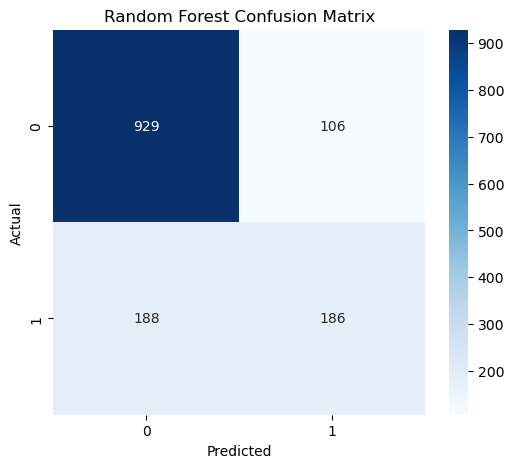

In [28]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#### Feature Importance

In [29]:
feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": rf_model.feature_importances_
    }
)

In [30]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.193201
1,tenure,0.171705
2,MonthlyCharges,0.168201
10,InternetService_Fiber optic,0.039103
28,PaymentMethod_Electronic check,0.038334
25,Contract_Two year,0.031360
4,gender_Male,0.028517
13,OnlineSecurity_Yes,0.027556
26,PaperlessBilling_Yes,0.025673
5,Partner_Yes,0.023302


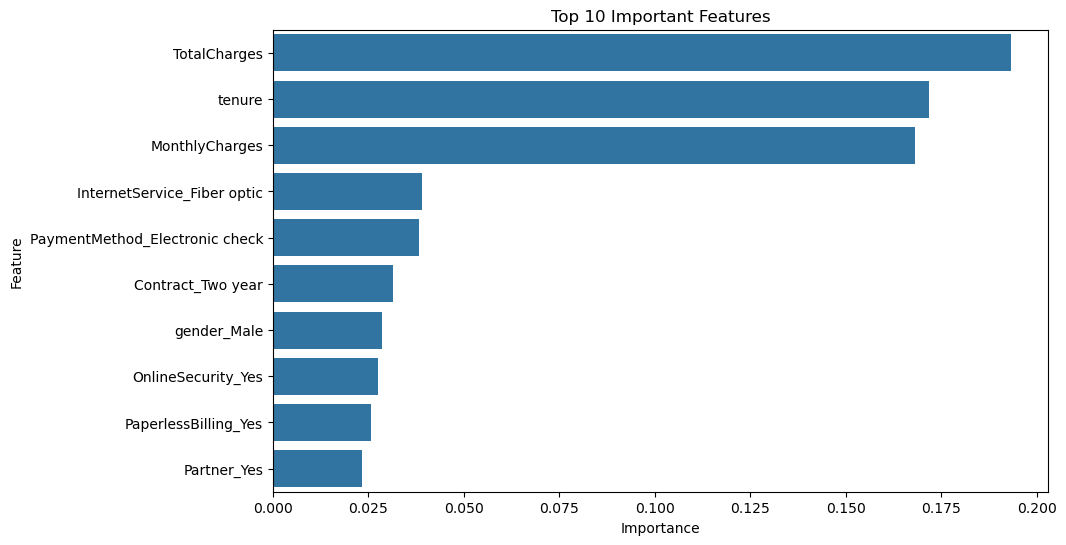

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

## Business Insight

The most influential factors affecting churn include:

- Contract Type
- Tenure
- Monthly Charges
- Total Charges

These variables significantly impact customer retention.

### Churn Probability

In [32]:
rf_probability = rf_model.predict_proba(
    X_test
)[:,1]

In [33]:
risk_df = pd.DataFrame(
    {
        "Churn_Probability":
        rf_probability
    }
)

risk_df.head()

,Churn_Probability
0,0.000
1,0.750
2,0.095
3,0.295
4,0.015


Customer Segmentation

In [34]:
def risk_category(prob):

    if prob >= 0.80:
        return "High Risk"

    elif prob >= 0.50:
        return "Medium Risk"

    else:
        return "Low Risk"

In [35]:
risk_df["Risk_Level"] = (
    risk_df["Churn_Probability"]
    .apply(risk_category)
)

In [36]:
risk_df["Risk_Level"].value_counts()

Risk_Level
Low Risk       1115
Medium Risk     218
High Risk        76
Name: count, dtype: int64

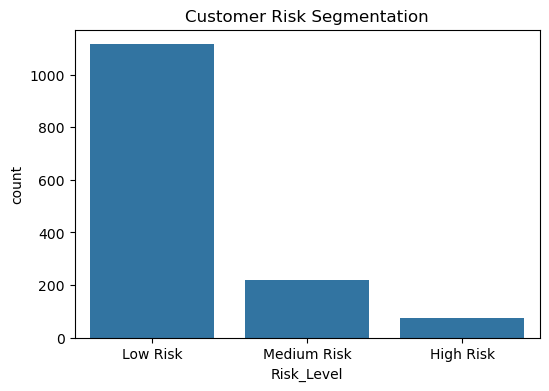

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Risk_Level",
    data=risk_df
)

plt.title("Customer Risk Segmentation")

plt.show()

In [38]:
feature_importance.head(20)

,Feature,Importance
3,TotalCharges,0.193201
1,tenure,0.171705
2,MonthlyCharges,0.168201
10,InternetService_Fiber optic,0.039103
28,PaymentMethod_Electronic check,0.038334
25,Contract_Two year,0.031360
4,gender_Male,0.028517
13,OnlineSecurity_Yes,0.027556
26,PaperlessBilling_Yes,0.025673
5,Partner_Yes,0.023302


In [39]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

In [40]:
import os

os.listdir("../data/processed")

['feature_importance.csv']

# Executive Summary

Model Findings:

1. Random Forest achieved strong predictive performance.

2. Contract type is one of the strongest churn indicators.

3. Customers with shorter tenure are more likely to churn.

4. Higher monthly charges increase churn risk.

5. Risk segmentation allows targeted retention strategies.

Business Impact:

The platform can proactively identify customers likely to leave and support retention decisions.